In [1]:
#@title Step 1: Importing the necessary libraries
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import pickle
import time
import itertools
import os

# from google.colab import drive
# drive.mount('/content/drive')


In [2]:
#@title Step 2: Load preprocessed (sequenced) data; Splitting data into training and testing datasets

import pickle

# Load sequences and vehicle IDs from a file
#with open('/content/drive/MyDrive/2024-05- 7088CEM (ANN Module)/Assignments/handover_prediction/Data/sequences_vehicle_ids.pkl', 'rb') as f:
with open('Data/sequences_vehicle_ids.pkl', 'rb') as f:
    sequences, vehicle_ids = pickle.load(f)

# Split data into training and testing
train_size = int(0.8 * len(sequences))
train_sequences = sequences[:train_size]
test_sequences = sequences[train_size:]
train_vehicle_ids = vehicle_ids[:train_size]
test_vehicle_ids = vehicle_ids[train_size:]

class VehicleDataset(Dataset):
    def __init__(self, sequences, flatten=False):
        self.sequences = sequences
        self.flatten = flatten # new

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq, target = self.sequences[idx]
        seq_tensor = torch.Tensor(seq)
        if self.flatten:
            seq_tensor = seq_tensor.view(-1)  # Flatten the sequence
        return seq_tensor, torch.Tensor(target)

# Create DataLoader objects for the full dataset
train_dataset_all = VehicleDataset(train_sequences, flatten=False)
test_dataset_all = VehicleDataset(test_sequences, flatten=False)

train_loader = DataLoader(train_dataset_all, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset_all, batch_size=32, shuffle=False)


In [3]:
#@title Step 3: Defining the methods (architecture of NN layers and activation functions)

#### Step 3a: Define the Long Short-Term Memory (LSTM) model

import torch.nn as nn
import torch.nn.functional as F

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

#### Step 3b: Define the Gated Recurrent Unit (GRU) model

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out


#### Step 3c: Define the generic Recurrent Neural Network (RNN) model

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out


#### Step 3d: Define 1-d CNN (Conv1D) model

# Architecture: Input -> Conv1D + ReLU -> Pooling -> Conv1D + ReLU -> Pooling -> ... -> Global Average Pooling -> Fully Connected Layer -> Output            #### Repeat 'Conv1D + ReLU -> Pooling' for num_layers times
class Conv1DModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(Conv1DModel, self).__init__()
        self.conv_layers = nn.ModuleList()
        self.pool_layers = nn.ModuleList()

        # Dynamically calculate padding and stride based on the number of layers
        for i in range(num_layers):
            if i == 0:
                self.conv_layers.append(nn.Conv1d(input_size, hidden_size, kernel_size=3, padding=1))
            else:
                self.conv_layers.append(nn.Conv1d(hidden_size, hidden_size, kernel_size=3, padding=1))

            # Only add pooling layer if it's not the last layer
            if i < num_layers - 1:
                self.pool_layers.append(nn.MaxPool1d(kernel_size=2, stride=1))

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.transpose(1, 2)  # Swap dimensions to fit Conv1d input format

        # Dynamically apply convolution and pooling layers
        for conv, pool in zip(self.conv_layers, self.pool_layers):
            x = F.relu(conv(x))
            x = pool(x)
            if x.size(2) <= 1:
                break  # Prevent invalid output size by stopping early if output size is too small

        x = x.mean(dim=2)  # Global average pooling
        x = self.fc(x)
        return x
    
#### Step 3e: Define a simple Multi-layer Perceptron (MLP) model

class MLPModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(MLPModel, self).__init__()
        layers = [nn.Linear(input_size, hidden_size), nn.ReLU()]

        for _ in range(1, num_layers):
            layers.extend([nn.Linear(hidden_size, hidden_size), nn.ReLU()])

        layers.append(nn.Linear(hidden_size, output_size))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x.view(x.size(0), -1))

In [4]:
#@title Step 4: Training method (generic for all baselines)

def train_model(model, train_loader, criterion, optimizer, num_epochs=10, device='cuda', early_stopping_rounds=4, min_delta=0.01):
    model.to(device)
    epoch_times = []
    epoch_losses = []

    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        total_loss = 0
        for sequences, targets in train_loader:
            sequences, targets = sequences.to(device), targets.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        average_loss = total_loss / len(train_loader)
        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)
        epoch_losses.append(average_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {average_loss:.8f}, Time: {epoch_time:.2f}s')

        # Early stopping mechanism
        if epoch >= early_stopping_rounds:
          recent_losses = epoch_losses[-early_stopping_rounds:]
          if all(abs(recent_losses[i] - recent_losses[i-1]) < min_delta * recent_losses[i-1] for i in range(1, early_stopping_rounds)):
              print(f"Early stopping at epoch {epoch+1}")
              break

    return epoch_times, epoch_losses

In [5]:
#@title Step 5: Model Evaluation

from sklearn.metrics import mean_absolute_error, r2_score

def evaluate_model(model, test_loader, device='cuda'):
    # device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)

    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for sequences, targets in test_loader:
            sequences, targets = sequences.to(device), targets.to(device)
            outputs = model(sequences)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(targets.cpu().numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f'RMSE: {rmse:.8f}')
    print(f'MAE: {mae:.8f}')
    print(f'R2 Score: {r2:.8f}')

    return predictions, actuals, rmse, mae, r2

In [8]:
#@title Step 6: Define a method to run the training and evaluation of the model for different sets of hyperparameters
import joblib
import pickle

# def run_experiment(params, input_size=4, output_size=2, model_type='LSTM', save_dir='/content/drive/MyDrive/2024-05- 7088CEM (ANN Module)/Assignments/handover_prediction/'):
def run_experiment(params, input_size=4, output_size=2, model_type='LSTM', save_dir='Experiments/Final/'):
    # hidden_size, num_layers, learning_rate, num_epochs = params
    
    # Ensure the parameters are the correct data type
    hidden_size = int(params[0])
    num_layers = int(params[1])
    learning_rate = float(params[2])
    num_epochs = int(params[3])

    if model_type == 'LSTM':
        model = LSTMModel(input_size, hidden_size, num_layers, output_size)
        save_path = 'Experiments/Final/experiment_results_LSTM.csv'
    elif model_type == 'GRU':
        model = GRUModel(input_size, hidden_size, num_layers, output_size)
        save_path = 'Experiments/Final/experiment_results_GRU.csv'
    elif model_type == 'RNN':
        model = RNNModel(input_size, hidden_size, num_layers, output_size)
        save_path = 'Experiments/Final/experiment_results_RNN.csv'
    elif model_type == 'Conv1D':
        model = Conv1DModel(input_size, hidden_size, num_layers, output_size)
        save_path = 'Experiments/Final/experiment_results_Conv1D.csv'
    elif model_type == 'MLP':
        example_input, _ = next(iter(train_loader))
        flattened_input_size = example_input.view(example_input.size(0), -1).size(1)
        model = MLPModel(flattened_input_size, hidden_size, num_layers, output_size)
        save_path = 'Experiments/Final/experiment_results_MLP.csv'
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    # Initialize criterion and optimizer
    criterion = nn.MSELoss() # mean squared error (MSE) is the criterion for evaluating loss in each epoch
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # Using Adam optimizer

    # Train the model and measure time
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    #%%%%%%% TRAIN %%%%%%
    # Use the provided train_model function
    epoch_times, epoch_losses = train_model(model, train_loader, criterion, optimizer, num_epochs=num_epochs, device=device)

    # Save the trained model
    model_save_path = os.path.join(save_dir, f'{model_type}_model.pth')
    torch.save(model.state_dict(), model_save_path)
    print(f"Saved {model_type} model to {model_save_path}")

    #%%%%%%% TEST %%%%%%
    # Evaluate the model
    predictions, actuals, rmse, mae, r2 = evaluate_model(model, test_loader, device=device)

    # Save predictions and actuals for each method
    data_save_path = os.path.join(save_dir, f'{model_type}_predictions_actuals.pkl')
    with open(data_save_path, 'wb') as f:
        joblib.dump((predictions, actuals), f) 

    # Calculate average epoch time
    avg_epoch_time = np.mean(epoch_times)

    result = {
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'learning_rate': learning_rate,
        'num_epochs': num_epochs,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'avg_epoch_time': avg_epoch_time,
        'epoch_times': epoch_times,
        'epoch_losses': epoch_losses
    }

    results_df = pd.DataFrame([result])
    if save_path:
        if os.path.exists(save_path):
            results_df.to_csv(save_path, mode='a', header=False, index=False)
        else:
            results_df.to_csv(save_path, index=False)

    return result, predictions, actuals


In [9]:
#@title Step 7a: Execute the experiment for each model type with the selected hyperparameters

import pandas as pd
import os

# set of hyperparameters for each model type consists of (hidden_size, num_layers, learning_rate, num_epochs)
# hyperparameters = {
#     'RNN': (100, 2, 0.001, 15),
#     'LSTM': (100, 4, 0.0005, 15),
#     'GRU': (100, 3, 0.0005, 15),
#     'Conv1D': (100, 2, 0.01, 10),
#     'MLP': (100, 3, 0.00005, 10)
# }

# Load the CSV file with the best hyperparameters for each method
file_path = 'Experiments/Tuning/best_hyperparam_sets_of_each_method.csv'
df = pd.read_csv(file_path)

# Extract the relevant columns for hyperparameters
hyperparameters = df.set_index('method')[['hidden_size', 'num_layers', 'learning_rate', 'num_epochs']].T.to_dict('list')

# Print the dictionary to verify
print(hyperparameters)

# Now you can use this hyperparameters dictionary in your experiment loop
predictions_dict = {}
actuals_dict = {}

# Loop through each model type and run the experiment with the corresponding hyperparameters
for model_type, params in hyperparameters.items():
    print(f"Running experiment for model {model_type} with parameters {params}")
    result, predictions, actuals = run_experiment(params, model_type=model_type)
    # Store the predictions and actuals
    predictions_dict[model_type] = predictions
    actuals_dict[model_type] = actuals
    print(f"Result for model {model_type}: {result}\n----------------------------\n")


{'RNN': [128.0, 2.0, 0.001, 30.0], 'LSTM': [100.0, 2.0, 0.0005, 30.0], 'GRU': [100.0, 3.0, 0.0005, 30.0], 'Conv1D': [100.0, 3.0, 5e-05, 30.0], 'MLP': [128.0, 2.0, 0.0001, 30.0]}
Running experiment for model RNN with parameters [128.0, 2.0, 0.001, 30.0]
Epoch [1/30], Loss: 193993.39481008, Time: 108.17s
Epoch [2/30], Loss: 1324.43166110, Time: 111.18s
Epoch [3/30], Loss: 5011.05701217, Time: 109.70s
Epoch [4/30], Loss: 8214.46379952, Time: 107.80s
Epoch [5/30], Loss: 4031.16454553, Time: 107.80s
Epoch [6/30], Loss: 10342.29719998, Time: 107.62s
Epoch [7/30], Loss: 13970.84681566, Time: 108.33s
Epoch [8/30], Loss: 11895.28409192, Time: 108.18s
Epoch [9/30], Loss: 12085.79180333, Time: 104.22s
Epoch [10/30], Loss: 11583.98337964, Time: 107.07s
Epoch [11/30], Loss: 10925.75223631, Time: 109.41s
Epoch [12/30], Loss: 13727.32835759, Time: 112.19s
Epoch [13/30], Loss: 12241.12345533, Time: 110.02s
Epoch [14/30], Loss: 11158.64783950, Time: 108.89s
Epoch [15/30], Loss: 10500.92980118, Time: 10

AttributeError: 'DataFrame' object has no attribute 'append'

In [14]:
#@title Step 7b:Combine the CSV files of all methods into one for further visualizations

import pandas as pd
import os

# Define the file paths (It was being saved in these files in run_experiment())
file_paths = {
    'LSTM': 'Experiments/Final/experiment_results_LSTM.csv',
    'RNN': 'Experiments/Final/experiment_results_RNN.csv',
    'GRU': 'Experiments/Final/experiment_results_GRU.csv',
    'MLP': 'Experiments/Final/experiment_results_MLP.csv',
    'Conv1D': 'Experiments/Final/experiment_results_Conv1D.csv'
}
# Initialize an empty DataFrame to store combined results
combined_results = pd.DataFrame()

# Loop through each method and its corresponding file path
for method, path in file_paths.items():
    if os.path.exists(path):
        # Load the CSV file into a DataFrame
        df = pd.read_csv(path)
        # Add the 'method' column
        df['method'] = method
        # Reorder columns to have 'method' as the first column
        df = df[['method'] + [col for col in df.columns if col != 'method']]
        # Append the DataFrame to the combined results
        combined_results = pd.concat([combined_results, df], ignore_index=True)
    else:
        print(f"File not found: {path}")

# Define the output file path
output_file_path = 'Experiments/Final/final_results_methods_comparison.csv'

# Save the combined results to the new CSV file
combined_results.to_csv(output_file_path, index=False)

print(f"\n-------------------\nCombined results saved to {output_file_path}")



-------------------
Combined results saved to Experiments/Final/final_results_methods_comparison.csv


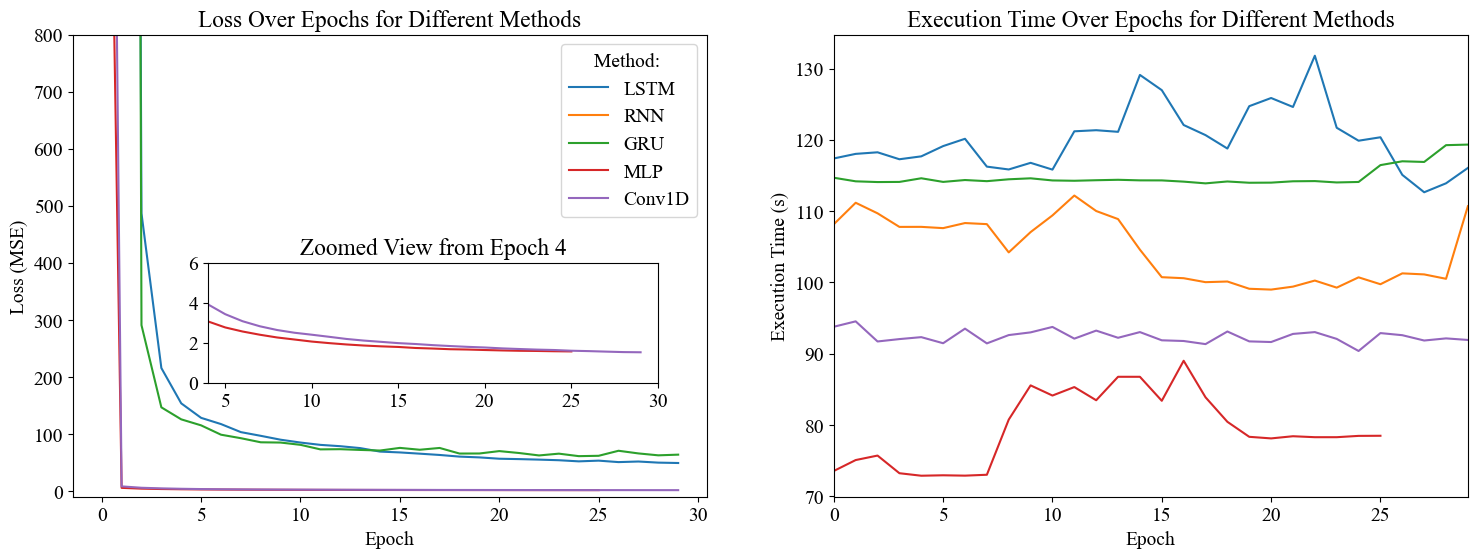

In [62]:
#@title Step 8a: Visualize results (Loss, Wall-Clock Time)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import ast

# Load the CSV file
file_path = 'Experiments/Final/final_results_methods_comparison.csv'
df = pd.read_csv(file_path)

# Set global font size to a smaller size
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # Set this to your desired smaller font size

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

########################
# First subplot: Loss Over Epochs for Different Methods
# Convert the 'epoch_losses' column from a string representation of a list to an actual list
df['epoch_losses'] = df['epoch_losses'].apply(ast.literal_eval)

for index, row in df.iterrows():
    axs[0].plot(row['epoch_losses'], label=row['method'])

axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss (MSE)')
axs[0].set_ylim(-10, 800)
axs[0].set_title('Loss Over Epochs for Different Methods')
axs[0].legend(title="Method: ")

# Create a small subplot manually within the first subplot
ax_inset = fig.add_axes([0.2, 0.3, 0.25, 0.2])  # [left, bottom, width, height]

for index, row in df.iterrows():
    ax_inset.plot(range(4, len(row['epoch_losses'])), row['epoch_losses'][4:], label=row['method'])

ax_inset.set_xlim(4, len(df.iloc[0]['epoch_losses']))
ax_inset.set_ylim(0, 6)
ax_inset.set_title('Zoomed View from Epoch 4')

########################
# Second subplot: Execution Time Over Epochs for Different Methods
# Convert the 'epoch_times' column from a string representation of a list to an actual list
df['epoch_times'] = df['epoch_times'].apply(ast.literal_eval)

for index, row in df.iterrows():
    axs[1].plot(row['epoch_times'], label=row['method'])

axs[1].set_xlabel('Epoch')
axs[1].set_xlim(0, 29)
axs[1].set_ylabel('Execution Time (s)')
axs[1].set_title('Execution Time Over Epochs for Different Methods')
# axs[1].legend(title="Method:", loc='center right', bbox_to_anchor=(1, 0.63))

# Save the figure before displaying
plt.savefig('Graphs/loss-and-exec-time-over-epochs.svg', bbox_inches='tight')

# Show the plot
plt.show()


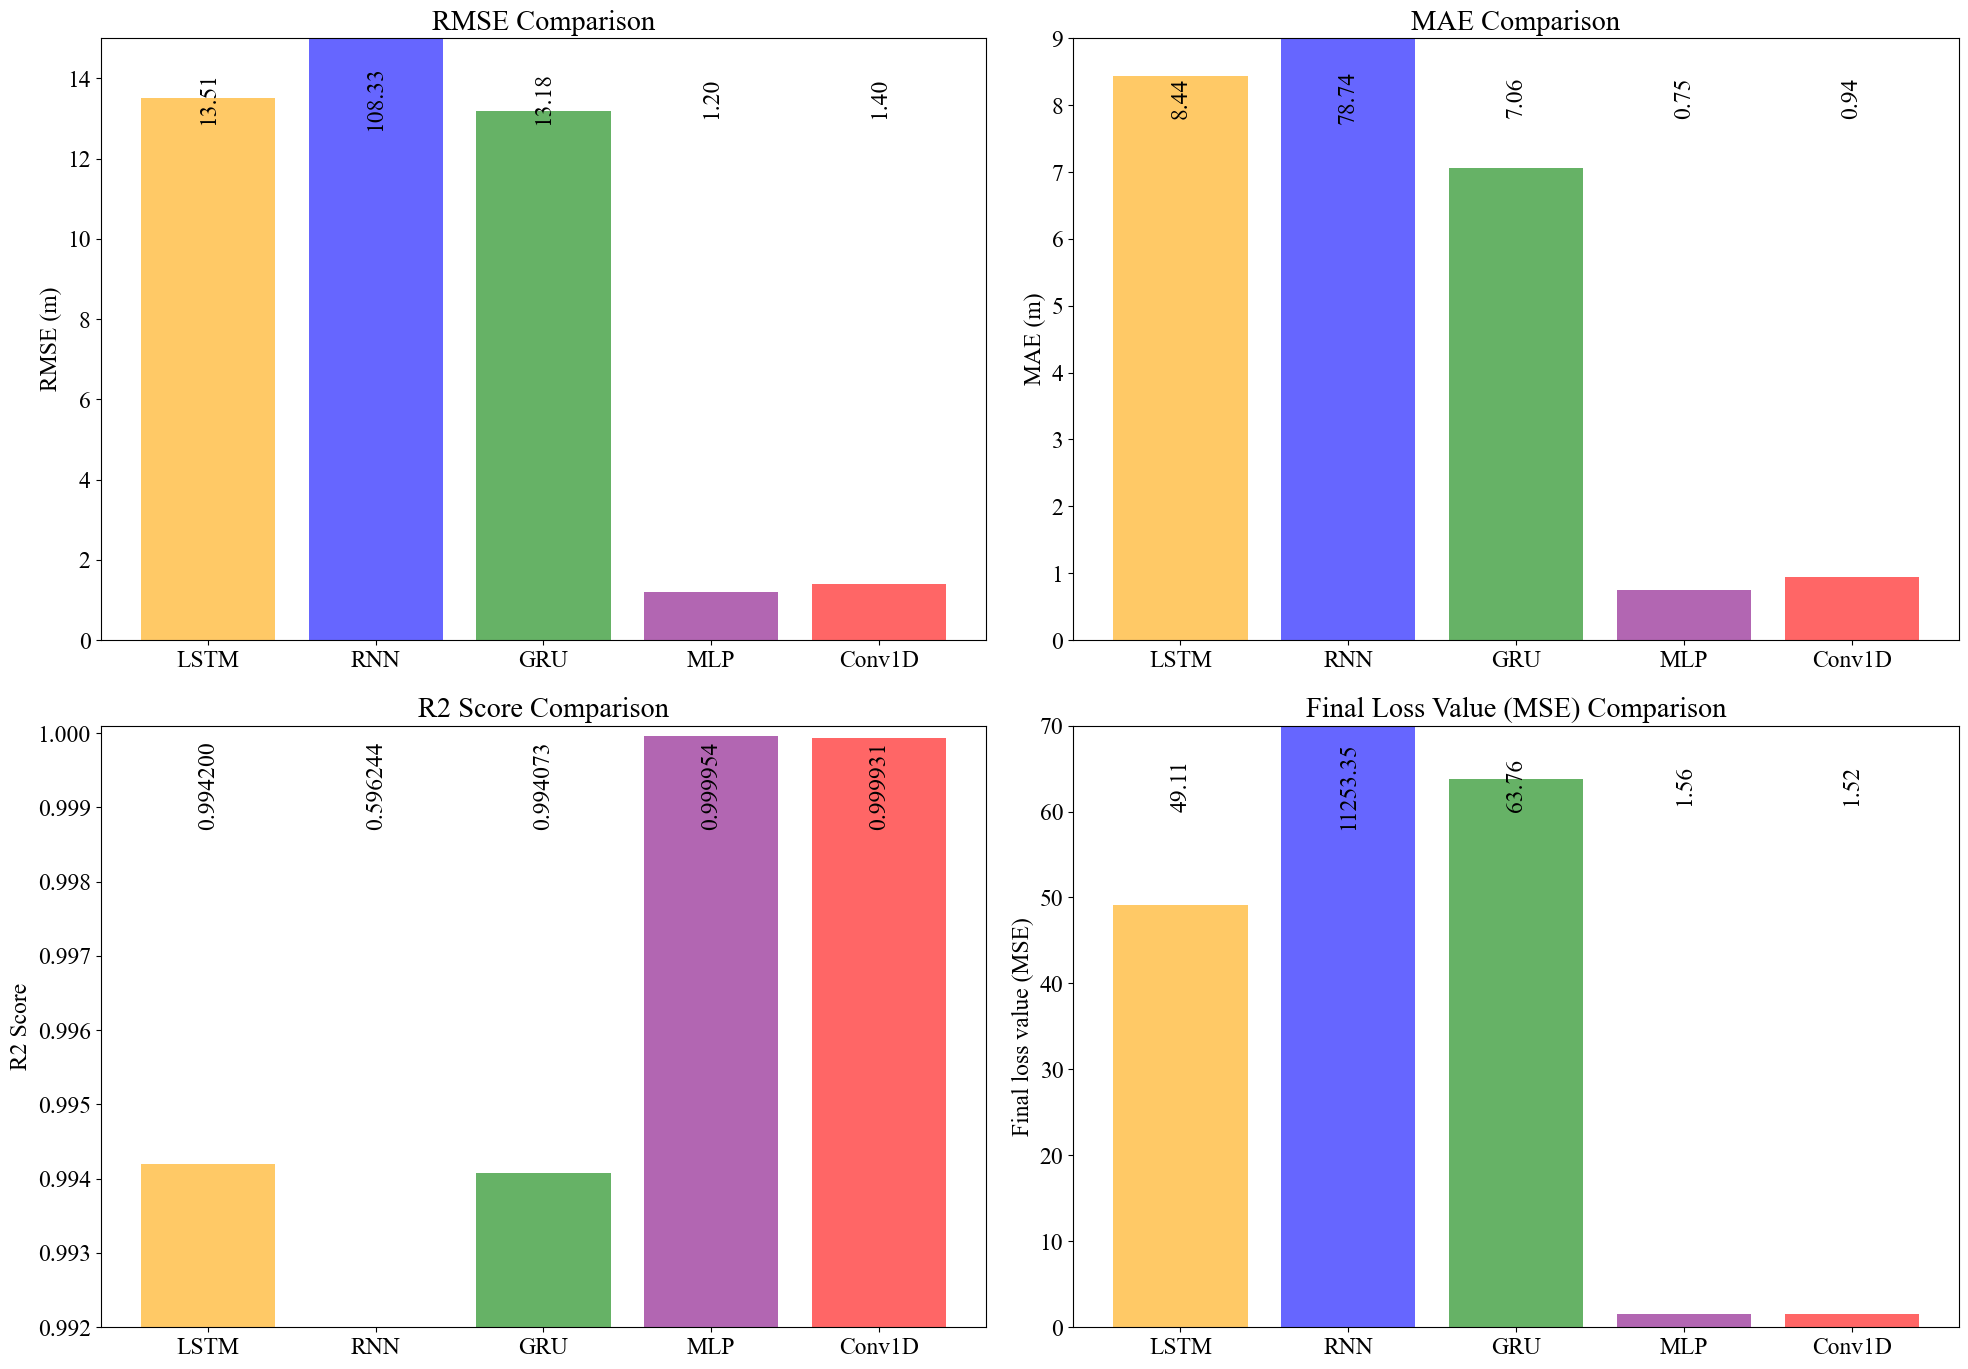

In [61]:
#@title Step 8c: Visualize results (RMSE, MAE, R2, and Final Loss Value for each method)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import ast

# Load the CSV file
file_path = 'Experiments/Final/final_results_methods_comparison.csv'
df = pd.read_csv(file_path)

# Convert the 'epoch_losses' column from a string representation of a list to an actual list (if it's not already a list)
df['epoch_losses'] = df['epoch_losses'].apply(lambda x: x if isinstance(x, list) else ast.literal_eval(x))

# Extract the metrics
methods = df['method']
rmse_values = df['rmse']
mae_values = df['mae']
r2_values = df['r2']
final_loss_values = df['epoch_losses'].apply(lambda x: x[-1]) # Extract final loss value from the last recorded epoch

# Define the original color mapping
color_mapping = {
    'RNN': 'blue',
    'LSTM': 'orange',
    'GRU': 'green',
    'Conv1D': 'red',
    'MLP': 'purple'
}

# Lighten the colors
def lighten_color(color, amount=0.7):
    return to_rgba(color, alpha=amount)

# Apply lighter colors
light_colors = [lighten_color(color_mapping[method], amount=0.6) for method in methods]

# Plotting RMSE, MAE, R2 Score, and Final Loss as bar plots
plt.rcParams['font.size'] = 17
fig, ax = plt.subplots(2, 2, figsize=(20, 14))  # Adjusted figsize to ensure adequate spacing

# Plot RMSE
ax[0, 0].bar(methods, rmse_values, color=light_colors)
ax[0, 0].set_ylabel('RMSE (m)')
ax[0, 0].set_ylim(0, 15) 
ax[0, 0].set_title('RMSE Comparison')
for i, v in enumerate(rmse_values):
    ax[0, 0].text(i, 0.9, f'{v:.2f}', ha='center', va='center', rotation=90, color='black', transform=ax[0, 0].get_xaxis_transform())

# Plot MAE
ax[0, 1].bar(methods, mae_values, color=light_colors)
ax[0, 1].set_ylabel('MAE (m)')
ax[0, 1].set_ylim(0, 9) 
ax[0, 1].set_title('MAE Comparison')
for i, v in enumerate(mae_values):
    ax[0, 1].text(i, 0.9, f'{v:.2f}', ha='center', va='center', rotation=90, color='black', transform=ax[0, 1].get_xaxis_transform())

# Plot R2 Score
ax[1, 0].bar(methods, r2_values, color=light_colors)
ax[1, 0].set_ylabel('R2 Score')
ax[1, 0].set_ylim(0.992, 1.0001)  # Limit the y-axis from 0.985 to 1.001
ax[1, 0].set_title('R2 Score Comparison')
for i, v in enumerate(r2_values):
    ax[1, 0].text(i, 0.9, f'{v:.6f}', ha='center', va='center', rotation=90, color='black', transform=ax[1, 0].get_xaxis_transform())

# Plot Final Loss Value (MSE)
ax[1, 1].bar(methods, final_loss_values, color=light_colors)
ax[1, 1].set_ylabel('Final loss value (MSE)')
ax[1, 1].set_ylim(0, 70) 
ax[1, 1].set_title('Final Loss Value (MSE) Comparison')
for i, v in enumerate(final_loss_values):
    ax[1, 1].text(i, 0.9, f'{v:.2f}', ha='center', va='center', rotation=90, color='black', transform=ax[1, 1].get_xaxis_transform())

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('Graphs/rmse-mae-r2score-finalloss-methods.svg', bbox_inches='tight')
plt.show()


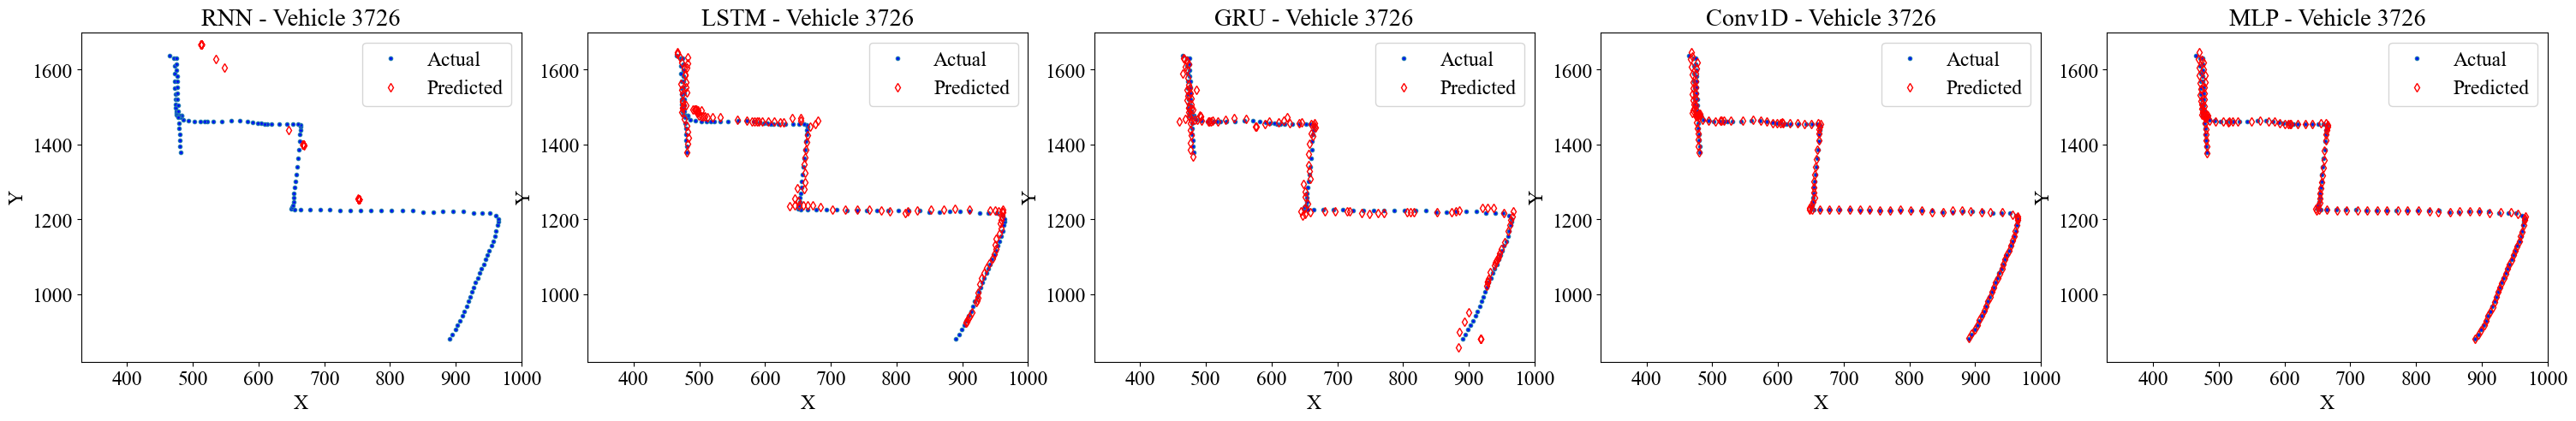

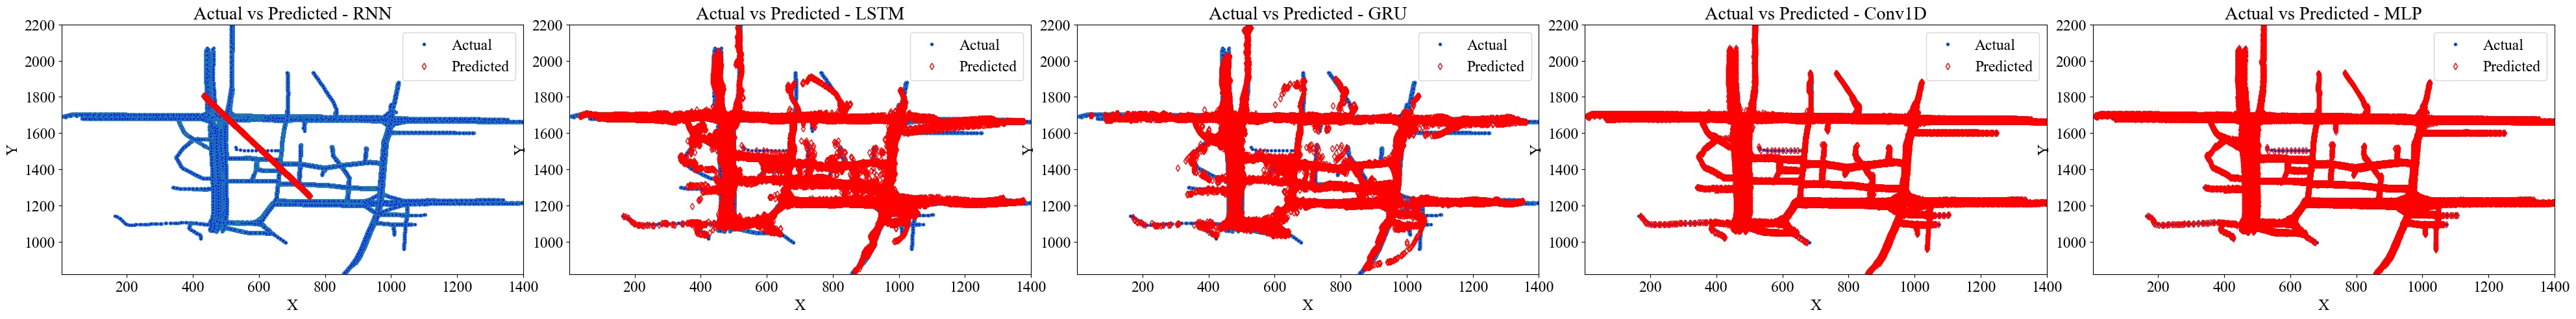

In [38]:
#@title Step 8a: Visualizing predictions vs actuals

import os
import joblib
import matplotlib.pyplot as plt
import numpy as np

def load_predictions_actuals(method_name, save_dir):
    data_save_path = os.path.join(save_dir, f'{method_name}_predictions_actuals.pkl')
    if os.path.exists(data_save_path):
        with open(data_save_path, 'rb') as f:
            predictions, actuals = joblib.load(f)
        return predictions, actuals
    else:
        raise FileNotFoundError(f"Data for {method_name} not found in {save_dir}.")


# def visualize_all_vehicles_all_methods(predictions_dict, actuals_dict, save_dir='/content/drive/MyDrive/2024-05- 7088CEM (ANN Module)/Assignments/handover_prediction/Experiments/Final/'):
def visualize_all_vehicles_all_methods(predictions_dict, actuals_dict, save_dir='Experiments/Final/'):
    methods = ['RNN', 'LSTM', 'GRU', 'Conv1D', 'MLP']

    # Load data if predictions_dict and actuals_dict are empty
    if not predictions_dict or not actuals_dict:
        for method in methods:
            try:
                predictions_dict[method], actuals_dict[method] = load_predictions_actuals(method, save_dir)
            except FileNotFoundError as e:
                print(e)
                return

    # Create subplots for each method
    fig, axes = plt.subplots(1, len(methods), figsize=(40, 5))

    for ax, method_name in zip(axes, methods):
        predictions = predictions_dict[method_name]
        actuals = actuals_dict[method_name]

        # Plot actuals with filled dots
        ax.plot(actuals[:, 0], actuals[:, 1], 'o',
                label='Actual', markersize=3, markerfacecolor='blue')

        # Plot predictions with void dots
        ax.plot(predictions[:, 0], predictions[:, 1], 'd',
                label='Predicted', markersize=5, markerfacecolor='none', markeredgecolor='red')

        ax.set_title(f'Actual vs Predicted - {method_name}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_xlim(2, 1400)
        ax.set_ylim(820, 2200)
        ax.legend()

    # Adjust layout to avoid overlap
    plt.subplots_adjust(left=0.02, right=0.98, wspace=0.1)

    # Save the figure as an SVG file
    # filename = 'all_vehicles_comparison.svg' # SVG File would be as lage as ~350 MB
    # output_path = os.path.join(save_dir, filename)
    # plt.savefig(output_path, bbox_inches='tight', dpi=10)

    # Save the figure as an PDF file
    filename = 'all_vehicles_comparison.pdf'
    output_path = os.path.join(save_dir, filename)
    plt.savefig(output_path, bbox_inches='tight', dpi=5)

    # Show the combined plot
    plt.show()

# def visualize_predictions_all_methods(predictions_dict, actuals_dict, vehicle_ids, random_seed=None, save_dir='/content/drive/MyDrive/2024-05- 7088CEM (ANN Module)/Assignments/handover_prediction/Experiments/Final/'):
def visualize_predictions_all_methods(predictions_dict, actuals_dict, vehicle_ids, random_seed=None, save_dir='Experiments/Final/'):
    methods = ['RNN', 'LSTM', 'GRU', 'Conv1D', 'MLP']

    # Load data if predictions_dict and actuals_dict are empty
    if not predictions_dict or not actuals_dict:
        for method in methods:
            try:
                predictions_dict[method], actuals_dict[method] = load_predictions_actuals(method, save_dir)
            except FileNotFoundError as e:
                print(e)
                return

    # Set the random seed for consistent vehicle selection
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Select a single random vehicle ID for visualization
    unique_ids = np.unique(vehicle_ids)
    sample_id = np.random.choice(unique_ids, 1, replace=False)[0]

    # Create subplots for each method
    fig, axes = plt.subplots(1, len(methods), figsize=(32, 5))
    
    for ax, method_name in zip(axes, methods):
        predictions = predictions_dict[method_name]
        actuals = actuals_dict[method_name]
        
        veh_indices = np.where(vehicle_ids == sample_id)[0]
        
        # Plot actuals with filled dots
        ax.plot(actuals[veh_indices, 0], actuals[veh_indices, 1], 'o',
                label='Actual', markersize=3, markerfacecolor='blue')

        # Plot predictions with void dots
        ax.plot(predictions[veh_indices, 0], predictions[veh_indices, 1], 'd',
                label='Predicted', markersize=5, markerfacecolor='none', markeredgecolor='red')

        ax.set_title(f'{method_name} - Vehicle {sample_id}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_xlim(330, 1000) # adjust as needed for the specific vehicle positions
        ax.set_ylim(820, 1700) # adjust as needed for the specific vehicle positions
        ax.legend()
    
    # Adjust layout to avoid overlap
    plt.subplots_adjust(left=0.05, right=0.95, wspace=0.15)

    # Save the figure as an SVG file
    filename = f'vehicle_{sample_id}_comparison.svg'
    output_path = os.path.join(save_dir, filename)
    plt.savefig(output_path, bbox_inches='tight')

    # Show the combined plot
    plt.show()

# Visualize example vehicle for all methods
visualize_predictions_all_methods(predictions_dict, actuals_dict, np.array(test_vehicle_ids), random_seed=100)

# Visualize all vehicles over all time steps for all methods
visualize_all_vehicles_all_methods(predictions_dict, actuals_dict)
